# Continuous-time RNN

This notebook trains a CTRNN on PerceptualDecisionMaking task and DelayComparison task,
then use **numerical fixed-point search** to uncover the decision geometry (line attractor).

The task data used in the tutorial is based on [NeuroGym](https://neurogym.github.io/neurogym/latest/), which is a curated collection of neuroscience tasks with a common interface to facilitate training of neural network models. The corresponding task description can be found in [this document](https://neurogym.github.io/neurogym/latest/api/tags/perceptual/)

> Reference: Yang, Guangyu Robert and Xiao-Jing Wang. “[Artificial Neural Networks for Neuroscientists: A Primer](https://doi.org/10.1016/j.neuron.2020.09.005).” Neuron 107 (2020): 1048 - 1070.

> Requires: `pip install neurogym` or manually install NeuroGym first and test with `import neurogym`.

## Setup

In [22]:
import sys
sys.path.append('../src')
from pathlib import Path
import pandas as pd
import torch, numpy as np, matplotlib.pyplot as plt
import neuralrnn
from neuralrnn import AutoConfig, AutoModel, Trainer, TrainingArguments
from neuralrnn import SupervisedObjective, load_dataset

# Fit PCA on all collected trial activity
from neuralrnn.analysis import fit_pca
from neuralrnn.analysis import find_fixed_points, linearize, dominant_direction

torch.manual_seed(0); np.random.seed(0)

# Trained checkpoints and generated figures live next to this notebook
MODEL_DIR = Path("./models/01")
FIG_DIR = Path("./figs/01")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

neuralrnn.__version__

'0.3.2.dev0'

# Part A: Perceptual Decision-Making

## 1. Task data

In [2]:
ds = load_dataset('perceptual_decision_making', batch_size=64, seq_len=100, dt=100)
print('input_dim =', ds.input_dim, '| n_actions =', ds.output_dim)


[TensorFlow DLL Diagnostic] Analyzing: d:\Anaconda\envs\chh_3_11\Lib\site-packages\tensorflow\python\_pywrap_tensorflow_internal.pyd
[Error] Failed to load _pywrap_tensorflow_common.dll: INITIALIZATION FAILED (0x45A) - The DLL's DllMain returned false.
    Hint: This often happens if your CPU lacks required instructions (like AVX/AVX2)
    or if the Microsoft Visual C++ Redistributable is outdated/missing.
input_dim = 3 | n_actions = 3


### Visualize sample trials

Plot a few trials to verify the task structure. The perceptual decision making requires integrating and comparing the left and right stimuli.
* Top row: input channels (fixation, stimulus-left, stimulus-right).
* Bottom row: target output (ground truth action).

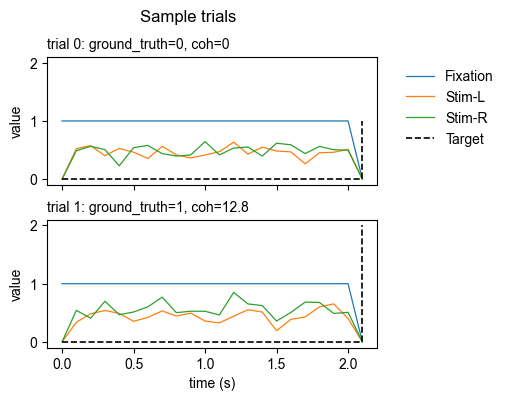

In [3]:
# Run a few trials and visualize input/output.
# sample_trials() pulls complete trials straight from the training dataset's
# held env — no second dataset (ds_viz) and no raw-env code needed.
from neuralrnn import visualization as viz

n_show = 2
fig, axes = viz.plot_trials(ds.sample_trials(n_show), dt=ds.dt,
                show_epochs=False, title='Sample trials', figsize=(4, 4))
channel_names = ['Fixation', 'Stim-L', 'Stim-R', 'Target']
axes[0].legend(channel_names, fontsize=10, frameon=False, bbox_to_anchor=(1.05, 1), loc="upper left")
fig.savefig(FIG_DIR / "sample_trials_pdm.png", dpi=150, bbox_inches='tight')
plt.show()


## 2. CTRNN + supervised training

NeuralRNN provides a two-step pipeline to get the RNN.
* **Building the model**: NeuralRNN follows the **transformers-like `AutoConfig` / `AutoModel` pattern** (see API for detailed description). Specifically, we set parameters including model_type, input/latent/output dim, dt (time constant), and other model-specific parameters (optional) in `AutoConfig` to define the model configuration. Then we use AutoModel to load and init the model. 
    
    In this notebook, we use the **CTRNN** (Continuous-Time RNN), a standard model for cognitive task optimization. Its dynamics follow:

    $$z_{t+1} = (1-\alpha)z_t + \alpha \cdot f(W_{rec} z_t + W_{in} x_t + b)$$

    where $\alpha = dt/\tau$ controls the timescale and $f$ is the activation function.

* **Training the model**: 

In [4]:
# Key step — load-first: reuse the saved checkpoint if it exists, else train
SAVE_DIR = MODEL_DIR / "ctrnn"
if (SAVE_DIR / "model.safetensors").exists():
    model = AutoModel.from_pretrained(SAVE_DIR)
    history = None
    print(f"Loaded pre-trained model from {SAVE_DIR}/")
else:
    cfg = AutoConfig.for_model('ctrnn', input_dim=ds.input_dim, latent_dim=32,
                               output_dim=ds.output_dim, dt=20, tau=100, 
                               # activation='sigmoid', # default is relu
                               # 'post_blend' puts the nonlinearity after blending: f((1-α)z + α·pre)
                               nonlinearity_mode='pre_activation')  
    model = AutoModel.from_config(cfg)
    objective = SupervisedObjective(task_type='classification')
    history = Trainer(
                model, ds, objective, 
                TrainingArguments(max_steps=2000, learning_rate=1e-3, log_every=200, 
                              # device='cuda', # you can set device to 'cuda' in TrainingArguments if GPU is available
                              )
            ).train()
    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(SAVE_DIR)
    print(f"Model saved to {SAVE_DIR}/")

Loaded pre-trained model from models\01\ctrnn/


In [17]:
# ---- Try to save and load a previously trained model ----
import os
SAVE_DIR = "./models/01/ctrnn"
os.makedirs(SAVE_DIR, exist_ok=True)
model.save_pretrained(SAVE_DIR)
print(f"\nModel saved to {SAVE_DIR}/")

model_loaded = AutoModel.from_pretrained(SAVE_DIR)
print(f"\nModel loaded from {SAVE_DIR}/")

# compare the weights of the original and loaded models
original_weights = model.h2h.weight.detach().cpu().numpy()
loaded_weights = model_loaded.h2h.weight.detach().cpu().numpy()
print(f"Are the weights equal: {np.allclose(original_weights, loaded_weights)}")


Model saved to ./models/01/ctrnn/

Model loaded from ./models/01/ctrnn/
Are the weights equal: True


## 3. Collect activity + PCA

Run the trained model on many trials to collect per-trial neural activity,
ground truth, and coherence. Then fit PCA and produce a publication-quality
visualization colored by condition.

In [6]:
# Collect per-trial activity, ground truth, coherence, and predicted actions.
# Trial-aligned dataset: pre-generated whole trials with the same interface as the
# built-in cognitive tasks (inputs/targets/mask/conditions).
num_trial = 500
# Complete trials straight from the training dataset (no new dataset needed).
# The returned Trials object exposes the same fields: inputs/targets/mask/conditions.
ds_analysis = ds.sample_trials(num_trial)

activity_dict = {}
trial_infos = {}
action_dict = {}

model.eval()
with torch.no_grad():
    out = model(ds_analysis.inputs)   # batched forward over all trials
states_all = out.states.numpy()       # (N, T, latent_dim)
logits_all = out.outputs.numpy()      # (N, T, output_dim)

for i, cond in enumerate(ds_analysis.conditions):
    n = cond['n_steps']               # true length of this trial (unpadded)
    activity_dict[i] = states_all[i, :n]
    trial_infos[i] = cond
    # argmax()-1: neurogym actions are 1-indexed (0=fix, 1=choice0, 2=choice1),
    # ground_truth is 0-indexed (0 or 1)
    action_dict[i] = logits_all[i, n - 1].argmax() - 1

# Build DataFrame and compute accuracy
df_trials = pd.DataFrame(trial_infos).T
df_trials['action'] = pd.Series(action_dict)
acc = (df_trials['action'] == df_trials['ground_truth']).mean()
print(f'Accuracy: {acc:.3f}')
print(f'Trial info example: {trial_infos[0]}')
print(f'Unique coherences: {sorted(df_trials["coh"].unique())}')

# Concatenate all activity for PCA fitting
activity_all = np.concatenate([activity_dict[i] for i in range(num_trial)], axis=0)
print(f'Activity shape for PCA: {activity_all.shape}')

Accuracy: 0.872
Trial info example: {'ground_truth': 0, 'coh': 25.6, 'epochs': {'fixation': (0, 1), 'stimulus': (1, 21), 'delay': (21, 21), 'decision': (21, 22)}, 'n_steps': 22, 'is_catch': False}
Unique coherences: [0.0, 6.4, 12.8, 25.6, 51.2]
Activity shape for PCA: (11000, 32)


Explained variance ratio: [0.912 0.057]


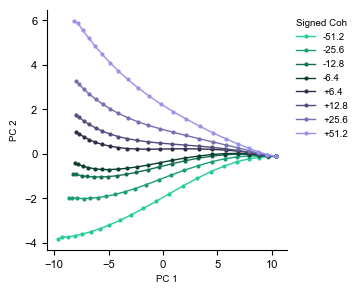

In [7]:
pca = fit_pca(activity_all, n_components=2)
print('Explained variance ratio:', np.round(pca.explained_variance_ratio, 3))

# --- Publication-quality PCA visualization ---
# Color scheme: green for ground_truth=0, purple for ground_truth=1
# Intensity modulated by coherence level
colors_rgb = np.array([[27, 158, 119], [117, 112, 179]]) / 255.  # green, purple

cohs = sorted(df_trials['coh'].unique())
cohs_pos = [c for c in cohs if c > 0]
color_intensity = [0.4, 0.7, 1.0, 1.3][:len(cohs_pos)]

fig = plt.figure(figsize=(4, 4))
ax = fig.add_axes([0.2, 0.2, 0.6, 0.6])

for ground_truth in [0, 1]:
    if ground_truth == 0:
        cohs_ = cohs_pos[::-1]
        color_intensity_ = color_intensity[::-1]
    else:
        cohs_ = cohs_pos
        color_intensity_ = color_intensity
    for i_coh, coh in enumerate(cohs_):
        trials_idx = df_trials[(df_trials['coh'] == coh) &
                               (df_trials['ground_truth'] == ground_truth)].index
        if len(trials_idx) == 0:
            continue
        activity_avg = np.mean([activity_dict[i] for i in trials_idx], axis=0)
        activity_pc = pca.transform(activity_avg)
        color = colors_rgb[ground_truth] * color_intensity_[i_coh]
        signed_coh = coh * (2 * ground_truth - 1)
        ax.plot(activity_pc[:, 0], activity_pc[:, 1], 'o-',
                color=color, ms=3, markeredgecolor='none', lw=1,
                label=f'{signed_coh:+.1f}')

ax.legend(title='Signed Coh', loc='upper left', bbox_to_anchor=(1.0, 1.0),
          frameon=False, fontsize=7)
ax.set_xlabel('PC 1', fontsize=7)
ax.set_ylabel('PC 2', fontsize=7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=8)
fig.savefig(FIG_DIR / "pca_trajectories_pdm.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Numerical fixed point search + line attractor

Search for approximate fixed points under the **0-coherence stimulus condition**
(fixation=1, left-stim=0.5, right-stim=0.5), then project onto the PCA plane
and draw the dominant eigenvector direction (line attractor).

Found 90 fixed points


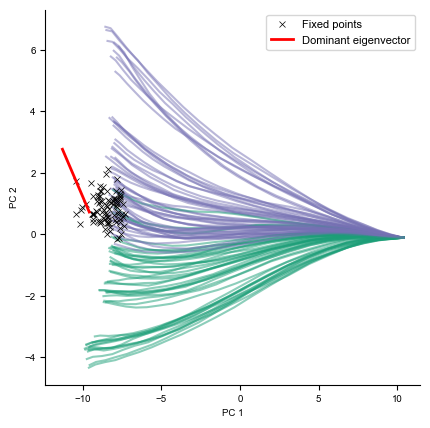

In [20]:
# 0-coherence stimulus input: fixation=1, left=0.5, right=0.5
# You can adjust the stimulus input to test a different condition.
task_input = torch.tensor([1, 0.5, 0.5], dtype=torch.float32)

# speed_tol controls the ||F(z)-z|| threshold for accepting converged candidates.
# Default 0.1 works well for typical 10k-step convergence (MSE ~1e-5 → speed ~0.01).
fps = find_fixed_points(model, backend='numeric', task_input=task_input,
                        n_candidates=128, n_iters=12000, speed_tol=0.1)
print(f'Found {len(fps)} fixed points')

# --- Visualize fixed points in PCA space ---
coords = pca.transform(fps.coords()) if len(fps) else np.empty((0, 2))

fig = plt.figure(figsize=(5, 5))
ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
colors_rgb = np.array([[27, 158, 119], [117, 112, 179]]) / 255.  # green, purple
# Overlay per-trial trajectories colored by ground truth
for i in range(min(100, num_trial)):
    activity_pc = pca.transform(activity_dict[i])
    color = colors_rgb[0] if trial_infos[i]['ground_truth'] == 0 else colors_rgb[1]
    ax.plot(activity_pc[:, 0], activity_pc[:, 1], color=color, alpha=0.5, ms=2)

if len(fps):
    ax.plot(coords[:, 0], coords[:, 1], 'kx', ms=5, mew=0.5, label='Fixed points')
    # Dominant eigenvector direction at first fixed point
    lin = linearize(model, fps.points[0].z, task_input=task_input)
    d = dominant_direction(lin)
    seg = pca.transform(np.array([fps.points[0].z + 2 * d,
                                   fps.points[0].z - 2 * d]))
    ax.plot(seg[:, 0], seg[:, 1], 'r-', lw=2, label='Dominant eigenvector')

ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.savefig(FIG_DIR / "fixed_points_pdm.png", dpi=150, bbox_inches='tight')
plt.show()

---

**Summary**: The model implements `recurrence`/`readout`; fixed points, linearization, and PCA
all come from the generic `analysis` module, shared with Paradigm B tutorials.

**Key differences from a naive implementation** (that may cause no stable fixed points):
1. `task_input` must be the **0-coherence stimulus** `[1, 0.5, 0.5]`, NOT zeros.
   Zero input drives all activity to zero trivially — no interesting fixed points exist there.
2. Use >=10000 optimization steps for convergence (loss should reach ~0).
3. Initialize candidates in `[0, 3)` (positive) to match ReLU activity range.
4. `speed_tol` (the `||F(z)−z||` acceptance threshold) must be set appropriately for the
   convergence level. After 10k steps the MSE is typically ~1e-5, giving speed ~0.01–0.04.
   The default `speed_tol=1e-5` was far too strict; `0.1` works well in practice.
   If you still get 0 fixed points, try increasing `n_iters` or relaxing `speed_tol`.

# Part B: Parametric Working Memory

Reproduce the second nn-brain tutorial: train a CTRNN on neurogym's **DelayComparison** (parametric working memory) task, then use numerical fixed-point search and Jacobian analysis to uncover the **line attractor** that supports working memory.

> This section continues from Part A. The same `analysis` module APIs are used.

## 1. Task: DelayComparison (Parametric Working Memory)

In this task, the network must compare two stimuli (v1, v2) separated by a variable delay, and report which was larger. The key feature: the delay period varies from 200ms to 3200ms, requiring the network to maintain a working memory of the first stimulus.

input_dim = 2 | n_actions = 3


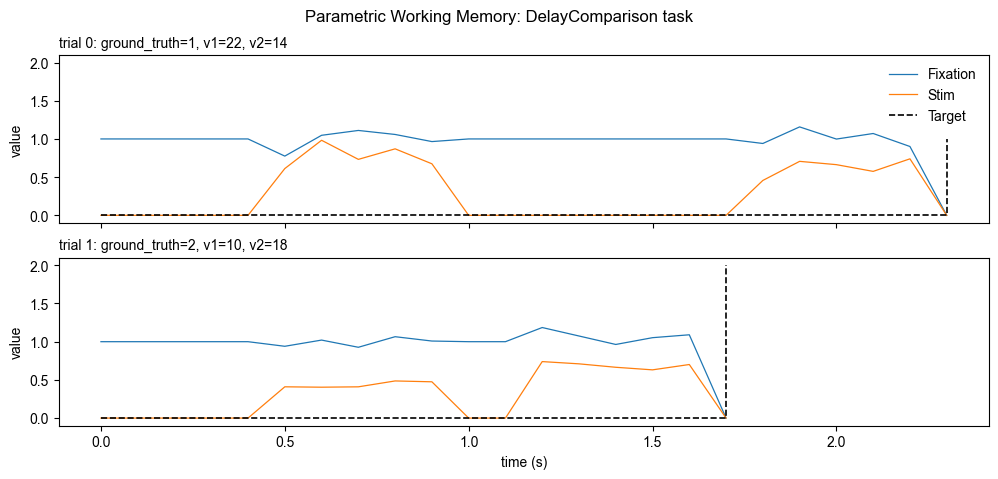

In [9]:
# Load the DelayComparison task via the registered dataset
timing = {'delay': ('choice', [200, 400, 800, 1600, 3200]),
          'response': ('constant', 500)}

ds_pw = load_dataset('delay_comparison', timing=timing,
                     batch_size=16, seq_len=100, dt=100)
print('input_dim =', ds_pw.input_dim, '| n_actions =', ds_pw.output_dim)

# Visualize sample trials — straight from the training dataset (no ds_viz)
from neuralrnn import visualization as viz

n_show = 2
fig, axes = viz.plot_trials(ds_pw.sample_trials(n_show), dt=ds_pw.dt, show_epochs=False,
                title='Parametric Working Memory: DelayComparison task')
channel_names = ['Fixation', 'Stim', 'Target']
axes[0].legend(channel_names, fontsize=10, frameon=False, )
fig.savefig(FIG_DIR / "sample_trials_pwm.png", dpi=150, bbox_inches='tight')
plt.show()

## 2. Train CTRNN on DelayComparison

In [21]:
# Train a new CTRNN on the DelayComparison task (load-first)
SAVE_DIR_PW = MODEL_DIR / "ctrnn_delay_comparison"
if (SAVE_DIR_PW / "model.safetensors").exists():
    model_pw = AutoModel.from_pretrained(SAVE_DIR_PW)
    history_pw = None
    print(f"Loaded pre-trained model from {SAVE_DIR_PW}/")
else:
    cfg_pw = AutoConfig.for_model('ctrnn', input_dim=ds_pw.input_dim, latent_dim=64,
                                   output_dim=ds_pw.output_dim, dt=100, tau=100)
    model_pw = AutoModel.from_config(cfg_pw)
    objective_pw = SupervisedObjective(task_type='classification')
    history_pw = Trainer(model_pw, ds_pw, objective_pw,
                         TrainingArguments(max_steps=2000, learning_rate=1e-3, log_every=200)).train()
    SAVE_DIR_PW.mkdir(parents=True, exist_ok=True)
    model_pw.save_pretrained(SAVE_DIR_PW)
    print(f"Model saved to {SAVE_DIR_PW}/")

Loaded pre-trained model from models\01\ctrnn_delay_comparison/


## 3. Collect activity + PCA visualization

Run the trained model on many trials with a **fixed long delay (3000ms)** for analysis. This makes the delay period long enough to clearly see the dynamics.

In [11]:
# Create dataset with fixed long delay for analysis (trial-aligned)
timing_analysis = {'delay': ('constant', 2000), 'response': ('constant', 500)}
ds_analysis = load_dataset('delay_comparison', timing=timing_analysis,
                           batch_size=16, n_trials=100, dt=100)

# Collect activity during delay period
num_trial_pw = len(ds_analysis)
activity_dict_pw = {}
trial_infos_pw = {}

model_pw.eval()
with torch.no_grad():
    out = model_pw(ds_analysis.inputs)   # batched forward over all trials
states_all = out.states.numpy()

for i, cond in enumerate(ds_analysis.conditions):
    # Extract activity during delay period only (epoch bounds from conditions)
    s, e = cond['epochs']['delay']
    activity_dict_pw[i] = states_all[i, s:e]
    trial_infos_pw[i] = cond

# Concatenate delay-period activity for PCA
activity_pw = np.concatenate([activity_dict_pw[i] for i in range(num_trial_pw)], axis=0)
print('Shape of delay-period neural activity:', activity_pw.shape)

# Print sample trial info
for i in range(5):
    print(f'Trial {i}:', trial_infos_pw[i])

Shape of delay-period neural activity: (2000, 64)
Trial 0: {'ground_truth': 2, 'vpair': (34, 26), 'v1': 26, 'v2': 34, 'epochs': {'fixation': (0, 5), 'stimulus1': (5, 10), 'delay': (10, 30), 'stimulus2': (30, 35), 'decision': (35, 36)}, 'n_steps': 36, 'is_catch': False}
Trial 1: {'ground_truth': 2, 'vpair': (22, 14), 'v1': 14, 'v2': 22, 'epochs': {'fixation': (0, 5), 'stimulus1': (5, 10), 'delay': (10, 30), 'stimulus2': (30, 35), 'decision': (35, 36)}, 'n_steps': 36, 'is_catch': False}
Trial 2: {'ground_truth': 1, 'vpair': (22, 14), 'v1': 22, 'v2': 14, 'epochs': {'fixation': (0, 5), 'stimulus1': (5, 10), 'delay': (10, 30), 'stimulus2': (30, 35), 'decision': (35, 36)}, 'n_steps': 36, 'is_catch': False}
Trial 3: {'ground_truth': 2, 'vpair': (34, 26), 'v1': 26, 'v2': 34, 'epochs': {'fixation': (0, 5), 'stimulus1': (5, 10), 'delay': (10, 30), 'stimulus2': (30, 35), 'decision': (35, 36)}, 'n_steps': 36, 'is_catch': False}
Trial 4: {'ground_truth': 1, 'vpair': (22, 14), 'v1': 22, 'v2': 14, 'e

Explained variance ratio: [0.824 0.109]


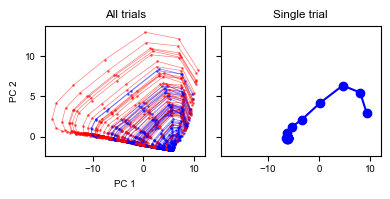

In [12]:
# Fit PCA on delay-period activity
pca_pw = fit_pca(activity_pw, n_components=2)
print('Explained variance ratio:', np.round(pca_pw.explained_variance_ratio, 3))

# Visualize individual trials colored by ground truth
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(4, 2))
for i in range(num_trial_pw):
    trial = trial_infos_pw[i]
    activity_pc = pca_pw.transform(activity_dict_pw[i])
    color = 'r' if trial['ground_truth'] == 1 else 'b'
    ax1.plot(activity_pc[:, 0], activity_pc[:, 1], 'o-', color=color,
             markersize=1, lw=0.5, alpha=0.5)
    if i < 1:
        ax2.plot(activity_pc[:, 0], activity_pc[:, 1], 'o-', color=color)

ax1.set_xlabel('PC 1')
ax1.set_ylabel('PC 2')
ax1.set_title('All trials')
ax2.set_title('Single trial')
plt.tight_layout()
fig.savefig(FIG_DIR / "pca_trajectories_pwm.png", dpi=150)
plt.show()

## 4. Fixed-point search for the line attractor

Search for approximate fixed points under the **0-coherence stimulus** (v1=v2, so the network should maintain equal memory of both stimuli). This reveals the line attractor along which the working memory is maintained.

Found 107 fixed points


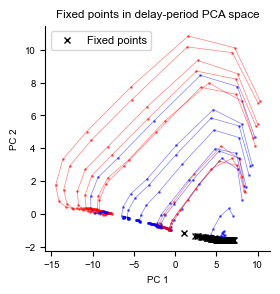

In [13]:
# Fixed point search with 0-coherence input (v1=v2)
# Input format: [stimulus1, stimulus2] - both equal for 0-coherence
task_input_pw = torch.tensor([1, 0], dtype=torch.float32)

fps_pw = find_fixed_points(model_pw, backend='numeric', task_input=task_input_pw,
                            n_candidates=128, n_iters=10000, speed_tol=0.5)
print(f'Found {len(fps_pw)} fixed points')

# Visualize fixed points in PCA space
coords_pw = pca_pw.transform(fps_pw.coords()) if len(fps_pw) else np.empty((0, 2))

fig = plt.figure(figsize=(3, 3))
ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
for i in range(min(20, num_trial_pw)):
    activity_pc = pca_pw.transform(activity_dict_pw[i])
    trial = trial_infos_pw[i]
    color = 'r' if trial['ground_truth'] == 1 else 'b'
    ax.plot(activity_pc[:, 0], activity_pc[:, 1], 'o-', color=color, alpha=0.5,
            markersize=1, lw=0.5)

if len(fps_pw):
    ax.plot(coords_pw[:, 0], coords_pw[:, 1], 'x', ms=5, color='black', label='Fixed points')

ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_title('Fixed points in delay-period PCA space')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.savefig(FIG_DIR / "fixed_points_pwm.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Jacobian analysis and line attractor

Compute the Jacobian at a fixed point near the center of the attractor manifold, then find the dominant eigenvector direction. This reveals the **line attractor** along which evidence is integrated.

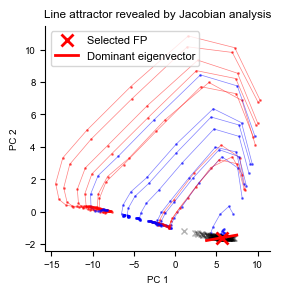

Eigenvalues at selected FP (top 5 by magnitude):
  λ = 0.7933+0.0000j, |λ| = 0.7933
  λ = 0.4844+0.3124j, |λ| = 0.5764
  λ = 0.4844-0.3124j, |λ| = 0.5764
  λ = 0.5512+0.0000j, |λ| = 0.5512
  λ = 0.2032+0.4070j, |λ| = 0.4549


In [14]:
# Compute Jacobian at a central fixed point
if len(fps_pw) > 0:
    # Choose fixed point closest to center (by sorting PC1)
    fp_coords = fps_pw.coords()
    i_fp = np.argsort(fp_coords[:, 0])[len(fp_coords) // 2]
    
    # Linearize around this fixed point
    lin = linearize(model_pw, fps_pw.points[i_fp].z, task_input=task_input_pw)
    d = dominant_direction(lin)
    
    # Project dominant direction onto PCA space
    fp_z = fps_pw.points[i_fp].z
    end_pts = np.array([fp_z + 2 * d, fp_z - 2 * d])
    end_pts_pc = pca_pw.transform(end_pts)
    
    # Plot
    fig = plt.figure(figsize=(3, 3))
    ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
    
    for i in range(min(20, num_trial_pw)):
        activity_pc = pca_pw.transform(activity_dict_pw[i])
        trial = trial_infos_pw[i]
        color = 'r' if trial['ground_truth'] == 1 else 'b'
        ax.plot(activity_pc[:, 0], activity_pc[:, 1], 'o-', color=color, alpha=0.5,
                markersize=1, lw=0.5)
    
    # Plot fixed points
    ax.plot(coords_pw[:, 0], coords_pw[:, 1], 'x', ms=5, color='black', alpha=0.3)
    ax.plot(coords_pw[i_fp, 0], coords_pw[i_fp, 1], 'x', ms=8, color='red', mew=2,
            label='Selected FP')
    
    # Plot line attractor direction
    ax.plot(end_pts_pc[:, 0], end_pts_pc[:, 1], '-', color='red', lw=2,
            label='Dominant eigenvector')
    
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    ax.set_title('Line attractor revealed by Jacobian analysis')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.savefig(FIG_DIR / "line_attractor_pwm.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print eigenvalue information
    eigvals = lin.eigenvalues
    print(f'Eigenvalues at selected FP (top 5 by magnitude):')
    sorted_idx = np.argsort(-np.abs(eigvals))
    for idx in sorted_idx[:5]:
        print(f'  λ = {eigvals[idx]:.4f}, |λ| = {np.abs(eigvals[idx]):.4f}')
else:
    print('No fixed points found. Try relaxing speed_tol or increasing n_iters.')

Now create a publication-quality figure showing the neural dynamics organized by stimulus value (v1), with and without the line attractor overlay, as in the reference Figure 6.

C:\Users\heiheihei\AppData\Local\Temp\ipykernel_39632\2928646715.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('winter')
C:\Users\heiheihei\AppData\Local\Temp\ipykernel_39632\2928646715.py:32: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(activity_pc[0, 0], activity_pc[0, 1], 'o-', alpha=alpha,


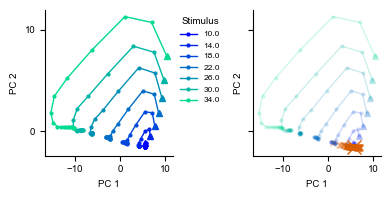

In [15]:
# Publication-quality figure: dynamics colored by stimulus value
import pandas as pd
import matplotlib as mpl

# Build DataFrame from trial info
df_pw = pd.DataFrame(trial_infos_pw).T

# Two-panel figure: without and with fixed points
fig, axes = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(4, 2))
colors_rgb = np.array([[27, 158, 119], [117, 112, 179], [217, 95, 2]]) / 255.

for panel_idx in range(2):
    ax = axes[panel_idx]
    plot_fp = (panel_idx == 1)
    
    # Group by v1 stimulus value
    values = np.unique(df_pw['v1'])
    cmap = mpl.cm.get_cmap('winter')
    alpha = 0.2 if plot_fp else 1.0
    
    for i, val in enumerate(values):
        trials = df_pw[df_pw['v1'] == val].index
        if len(trials) == 0:
            continue
        activity = np.mean([activity_dict_pw[i] for i in trials], axis=0)
        activity_pc = pca_pw.transform(activity)
        label = f'{val:.1f}'
        color = cmap(i / len(values))
        ax.plot(activity_pc[:, 0], activity_pc[:, 1], 'o-',
                color=color, ms=3, markeredgecolor='none',
                lw=1, label=label, alpha=alpha)
        ax.plot(activity_pc[0, 0], activity_pc[0, 1], 'o-', alpha=alpha,
                marker='^', color=color, ms=5)
    
    if plot_fp and len(fps_pw) > 0:
        # Overlay fixed points and line attractor
        color = colors_rgb[2]
        ax.plot(coords_pw[:, 0], coords_pw[:, 1], 'x', ms=4, color=color, alpha=0.3)
        ax.plot(coords_pw[i_fp, 0], coords_pw[i_fp, 1], 'x', ms=10, color=color, lw=1)
        ax.plot(end_pts_pc[:, 0], end_pts_pc[:, 1], color=color)
    else:
        ax.legend(title='Stimulus', loc='upper left', bbox_to_anchor=(1.0, 1.0), frameon=False,
                  fontsize=6)
    
    ax.set_xlabel('PC 1', fontsize=7)
    ax.set_ylabel('PC 2', fontsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.locator_params(nbins=2)
fig.savefig(FIG_DIR / "dynamics_by_stimulus_pwm.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Eigenvalue distribution

Visualize the eigenvalues of the Jacobian in the complex plane to assess stability properties.

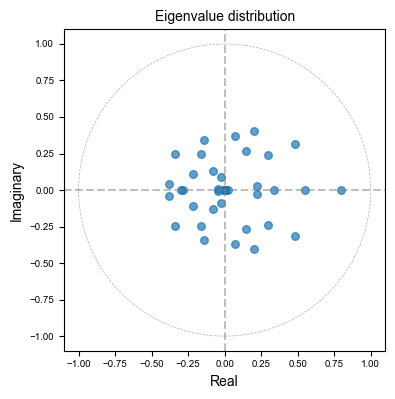

Stable eigenvalues (|λ|<1): 64/64


In [16]:
# Plot eigenvalue distribution in complex plane
if len(fps_pw) > 0:
    eigvals = lin.eigenvalues
    
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.scatter(np.real(eigvals), np.imag(eigvals), s=30, alpha=0.7)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    
    # Draw unit circle for reference
    theta = np.linspace(0, 2 * np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3, lw=0.5)
    
    ax.set_xlabel('Real', fontsize=10)
    ax.set_ylabel('Imaginary', fontsize=10)
    ax.set_title('Eigenvalue distribution', fontsize=10)
    ax.set_aspect('equal')
    plt.tight_layout()
    fig.savefig(FIG_DIR / "eigenvalues_pwm.png", dpi=150)
    plt.show()
    
    # Count stable eigenvalues (inside unit circle)
    n_stable = np.sum(np.abs(eigvals) < 1)
    print(f'Stable eigenvalues (|λ|<1): {n_stable}/{len(eigvals)}')
else:
    print('No fixed points found - cannot compute eigenvalues.')

---

**Summary (Part B)**: The DelayComparison task requires the network to maintain a working memory of the first stimulus during the delay period. The fixed-point analysis reveals a **line attractor** — a manifold of approximately stable fixed points along which the memory is maintained. The dominant eigenvector of the Jacobian at these fixed points aligns with this line attractor, confirming the dynamical mechanism underlying parametric working memory.